In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib_venn import venn2, venn3, venn3_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.37 GB, difference +2.37 GB
CPU times: user 589 ms, sys: 1.66 s, total: 2.25 s
Wall time: 6.72 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

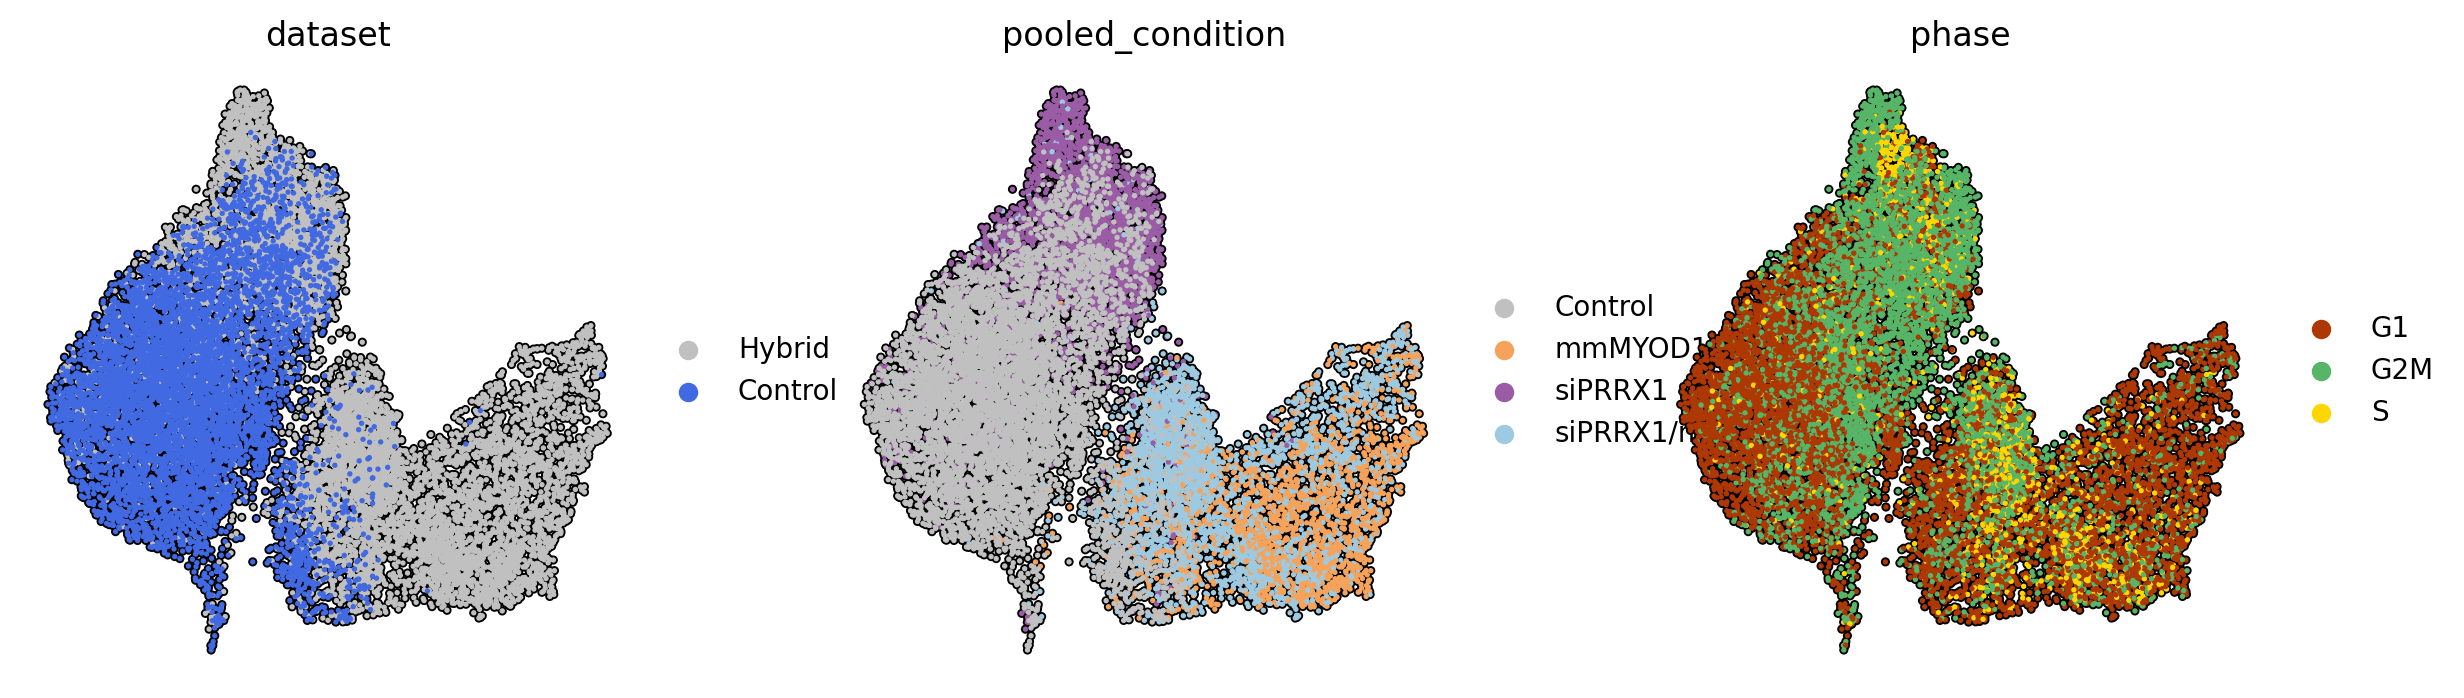

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

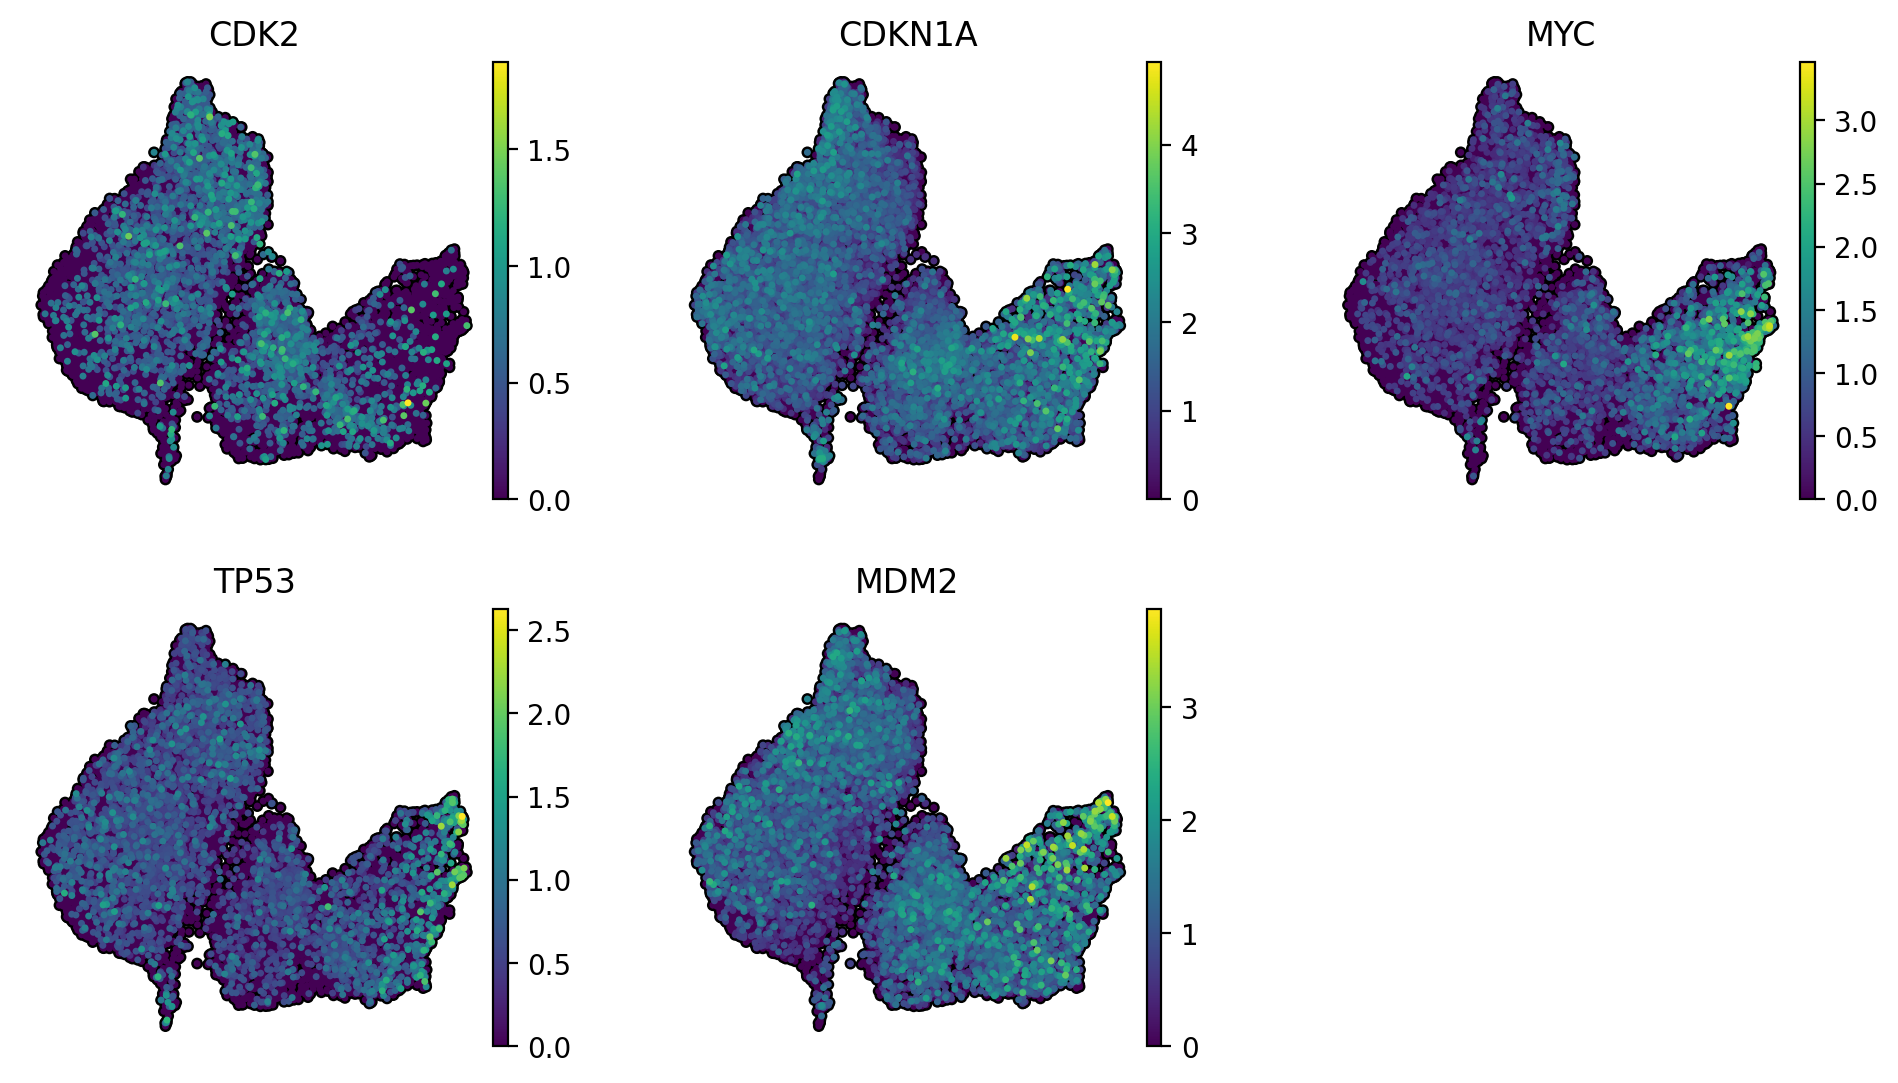

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

genes_to_plot = ['CDK2', 'CDKN1A', 'MYC', 'TP53', 'MDM2']
genes_to_plot = [g for g in genes_to_plot if g in adata.var_names]

sc.pl.umap(
    adata,
    color=genes_to_plot,
    size=25,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    layer='log_norm',
)

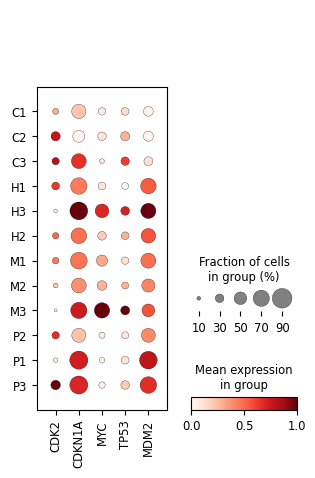

In [11]:
plt.rcdefaults()

sc.pl.dotplot(
    adata,
    var_names=genes_to_plot,
    # groupby='pooled_condition',
    groupby='leiden_split',
    dendrogram=False,
    layer='log_norm',
    standard_scale='var',
)

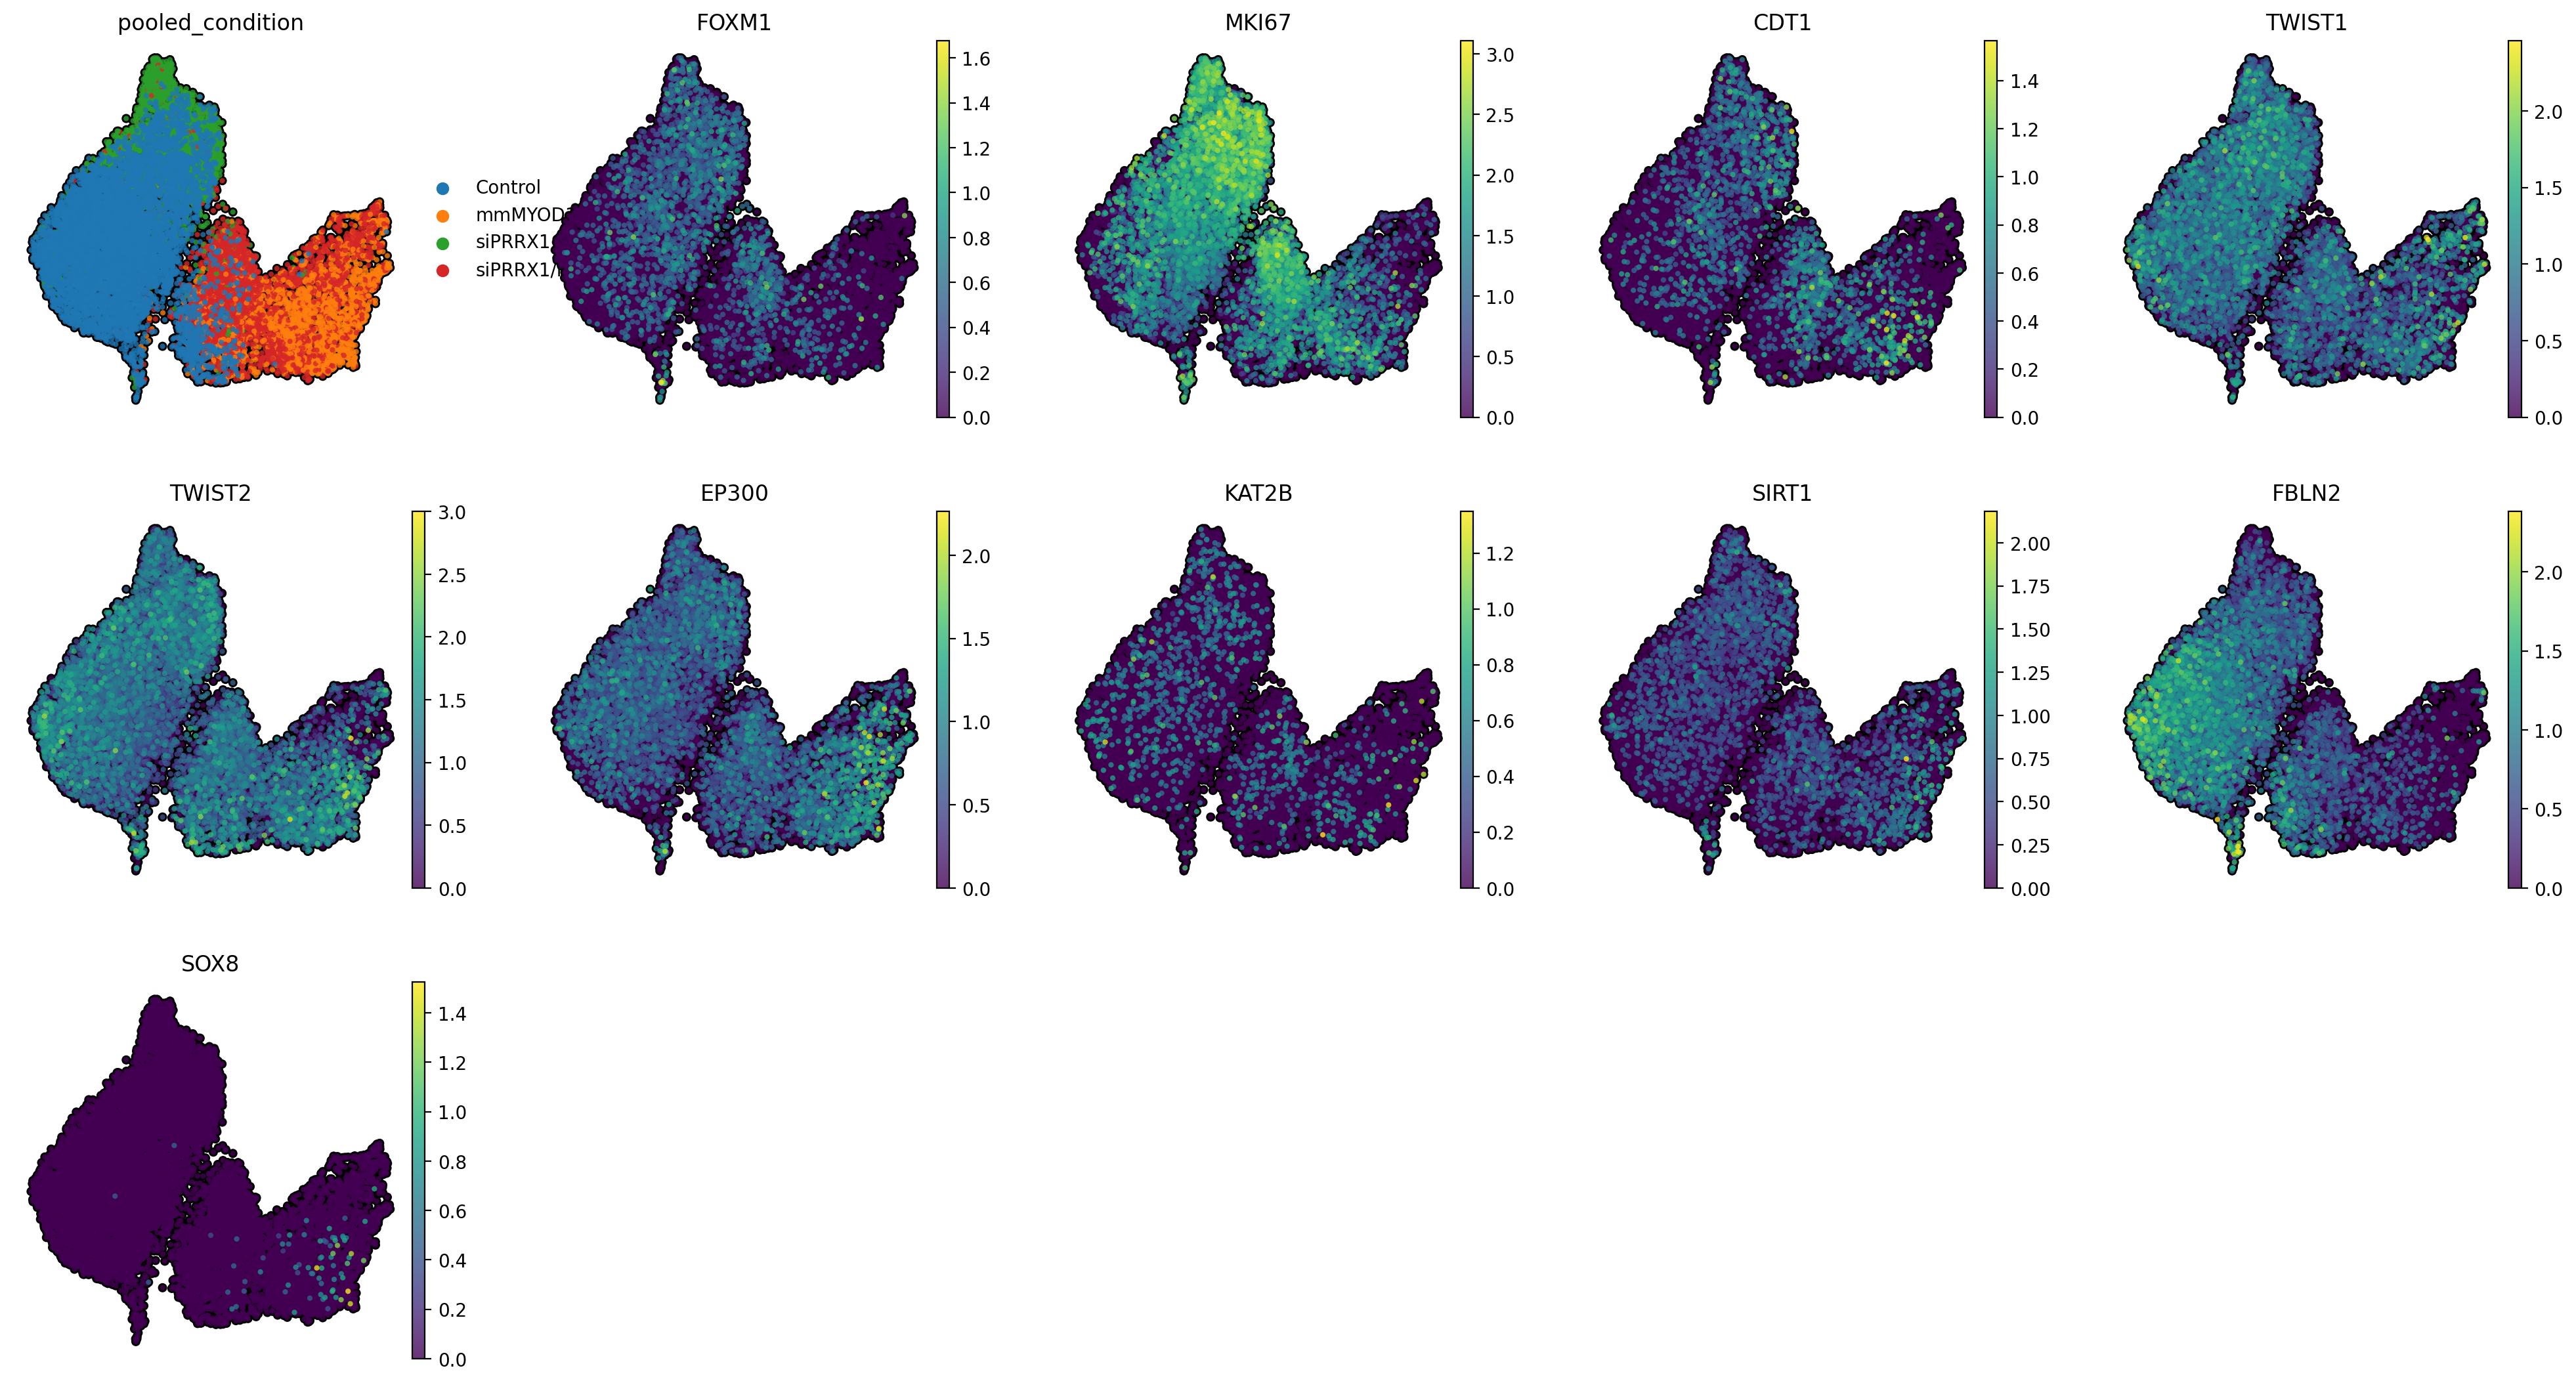

In [26]:
# genes = [
#     'SETD7', 'SETD9', 'PRMT5', 'KDM1A', # LSD1
#     'KDM6A' # UTX
#     'EP300', 'KAT3B', 'CREBBP',
#     'SMARCA4', # Brg1
#     'SUV39H1', 'EHMT2', 
#     'EZH2',
#     'SRA1', 'MRLN', 
#     'CTCF', 'CDKN1C',
# ]


genes = ['FOXM1', 'MKI67', 'CDT1', 'TWIST1', 'TWIST2', 'EP300', 'KAT2B', 'SIRT1', 'FBLN2', 'SOX8']

genes_to_plot = [g for g in genes if g in adata.var_names]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['pooled_condition'] + genes_to_plot,
    size=35,
    ncols=5,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=0.8,
    layer='log_norm',
)

# Load in gene sets

In [5]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(len(fib_genes))

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
220


# DGE

mmMYOD1, siPRRX1, siPRRX1/mmMYOD1, Controls

In [4]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]

    
    if pct_nz_thresh != 0.0:
        if 'pct_nz_reference' in tmp.columns:
            tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
        else:
            tmp = tmp[tmp['pct_nz_group'] > pct_nz_thresh]
            print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [7]:
# # all groups vs each other
# sc.tl.rank_genes_groups(
#     adata, 
#     groupby="pooled_condition",
#     method='wilcoxon',
#     corr_method='benjamini-hochberg',
#     use_raw=False,
#     layer='log_norm',
#     pts=True,
#     key_added='each_vs_rest',
# )

# hyb groups vs controls
sc.tl.rank_genes_groups(
    adata, 
    groupby="pooled_condition",
    reference='Control',
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='condition_vs_control',
)

ranking genes
    finished (0:01:03)


## Top DEGs per condition

In [11]:
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

sig = get_significant_DEGs(deg)#, pct_nz_thresh=0.2)

# filter for upregulated genes that are expressed in a certain proportion of cells
pct_thresh = 0.3

sig = sig[
    (sig['logfoldchanges'] < 0) | # retain all downregulated genes
    ((sig['logfoldchanges'] > 0) & (sig['pct_nz_group'] >= pct_thresh))
]

print(f'N genes: {sig['names'].nunique()}')

sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9882

N genes: 5132


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306


In [33]:
tmp = sig.sort_values(by=['group', 'scores'], ascending=[True, False])

tmp.groupby('group', observed=True)[['group', 'names', 'scores']].head(10)

,group,names,scores
0,mmMYOD1,MYOD1,69.678673
1,mmMYOD1,MT-ND4,69.559166
2,mmMYOD1,LINC-PINT,59.171329
3,mmMYOD1,NAV3,58.639927
4,mmMYOD1,TAF1D,55.636890
5,mmMYOD1,KCNQ5,54.305904
6,mmMYOD1,IFIT3,52.313427
7,mmMYOD1,SMURF2,51.317898
8,mmMYOD1,RIGI,49.269051
9,mmMYOD1,IFIT2,49.081940


In [12]:
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

pdf = pd.merge(sig, gdf, how='left', on='names')

print("Removing non protein-coding, unnamed, and mitochondrial genes...\n")

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes
# pdf = pdf[~pdf['ribo']] # remove ribosomal genes

print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}\n")

for i in pdf['group'].unique():
    tmp = pdf[pdf['group'] == i]
    print(f"N upregulated genes for {i}: {tmp[tmp['logfoldchanges'] > 0]['names'].nunique()}")
    print(f"N downregulated genes for {i}: {tmp[tmp['logfoldchanges'] < 0]['names'].nunique()}\n")

pdf.head()

Removing non protein-coding, unnamed, and mitochondrial genes...

N unique DE protein-coding genes: 4755

N upregulated genes for mmMYOD1: 1838
N downregulated genes for mmMYOD1: 1734

N upregulated genes for siPRRX1: 1557
N downregulated genes for siPRRX1: 940

N upregulated genes for siPRRX1/mmMYOD1: 1515
N downregulated genes for siPRRX1/mmMYOD1: 1302



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513,protein_coding,False,False
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840,protein_coding,False,False
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306,protein_coding,False,False
5,mmMYOD1,KCNQ5,54.305904,2.960109,0.0,0.0,0.952584,2.960109,protein_coding,False,False
6,mmMYOD1,IFIT3,52.313427,1.631886,0.0,0.0,0.984353,1.631886,protein_coding,False,False


In [17]:
pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False]).head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
0,mmMYOD1,MYOD1,69.678673,32.184513,0.000000e+00,0.000000e+00,1.000000,32.184513,protein_coding,False,False
905,mmMYOD1,TAS2R19,15.551889,11.040074,1.544808e-54,2.222003e-53,0.223329,11.040074,protein_coding,False,False
632,mmMYOD1,CHRNA1,18.197309,9.463173,5.420632e-74,1.049022e-72,0.261735,9.463173,protein_coding,False,False
316,mmMYOD1,TAS2R30,23.689327,9.032257,4.645199e-124,1.510715e-122,0.340920,9.032257,protein_coding,False,False
48,mmMYOD1,ESR1,38.310966,8.280114,0.000000e+00,0.000000e+00,0.552394,8.280114,protein_coding,False,False


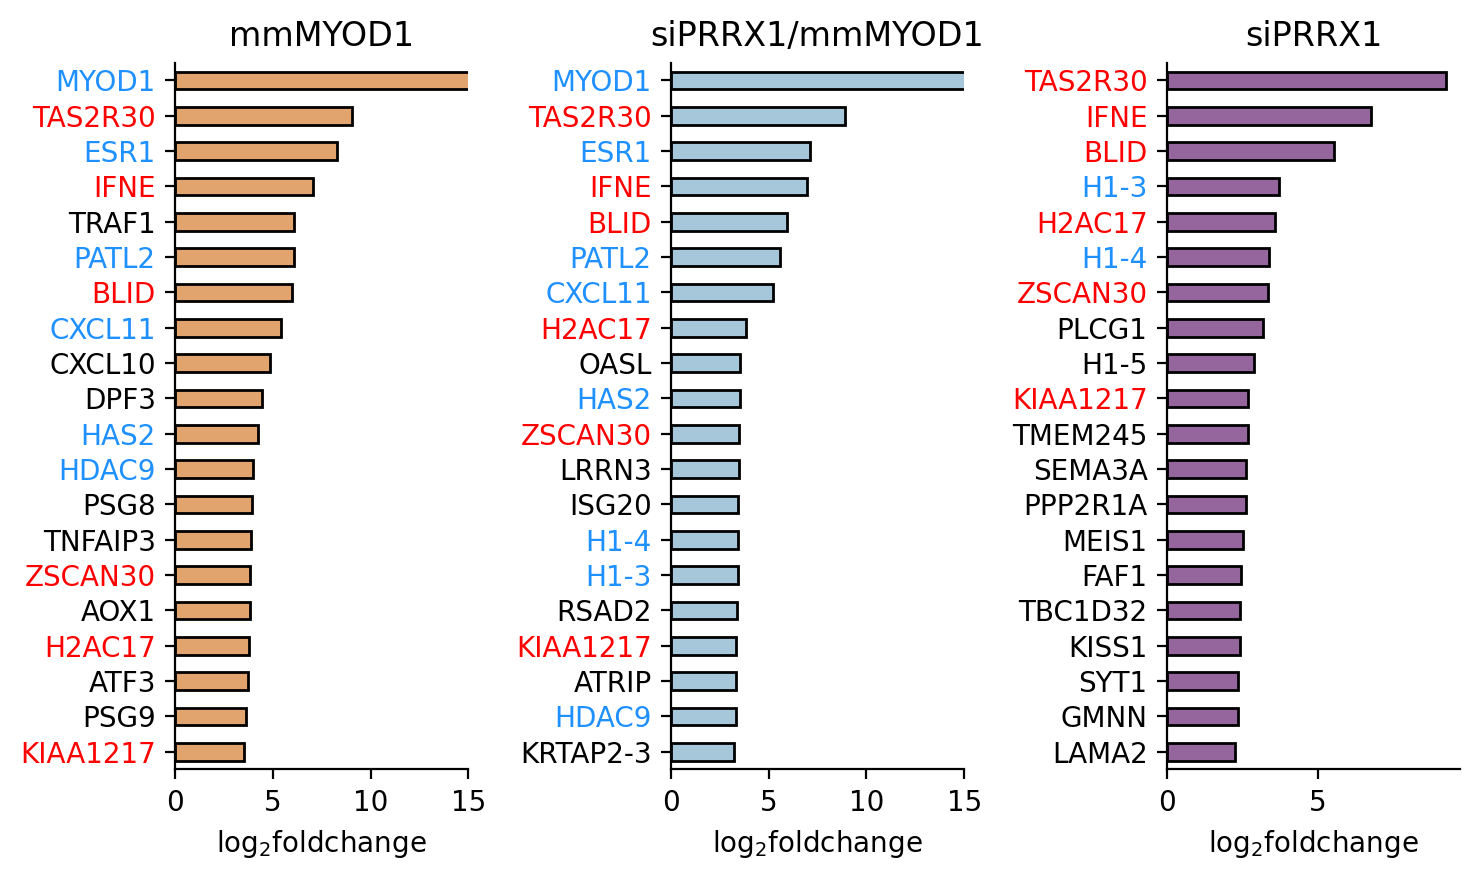

In [13]:
from collections import Counter

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

top_genes_per_group = {}

plot_order = ["mmMYOD1", "siPRRX1/mmMYOD1", "siPRRX1"]
color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

    if group == 'mmMYOD1':
        ax.set_xlim([0, 15])
        # ax.set_xscale('log')
    elif group == 'siPRRX1/mmMYOD1':
        ax.set_xlim([0, 15])
        # ax.set_xscale('log')
    # else:
    #     ax.set_xlim([0, 5])

    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

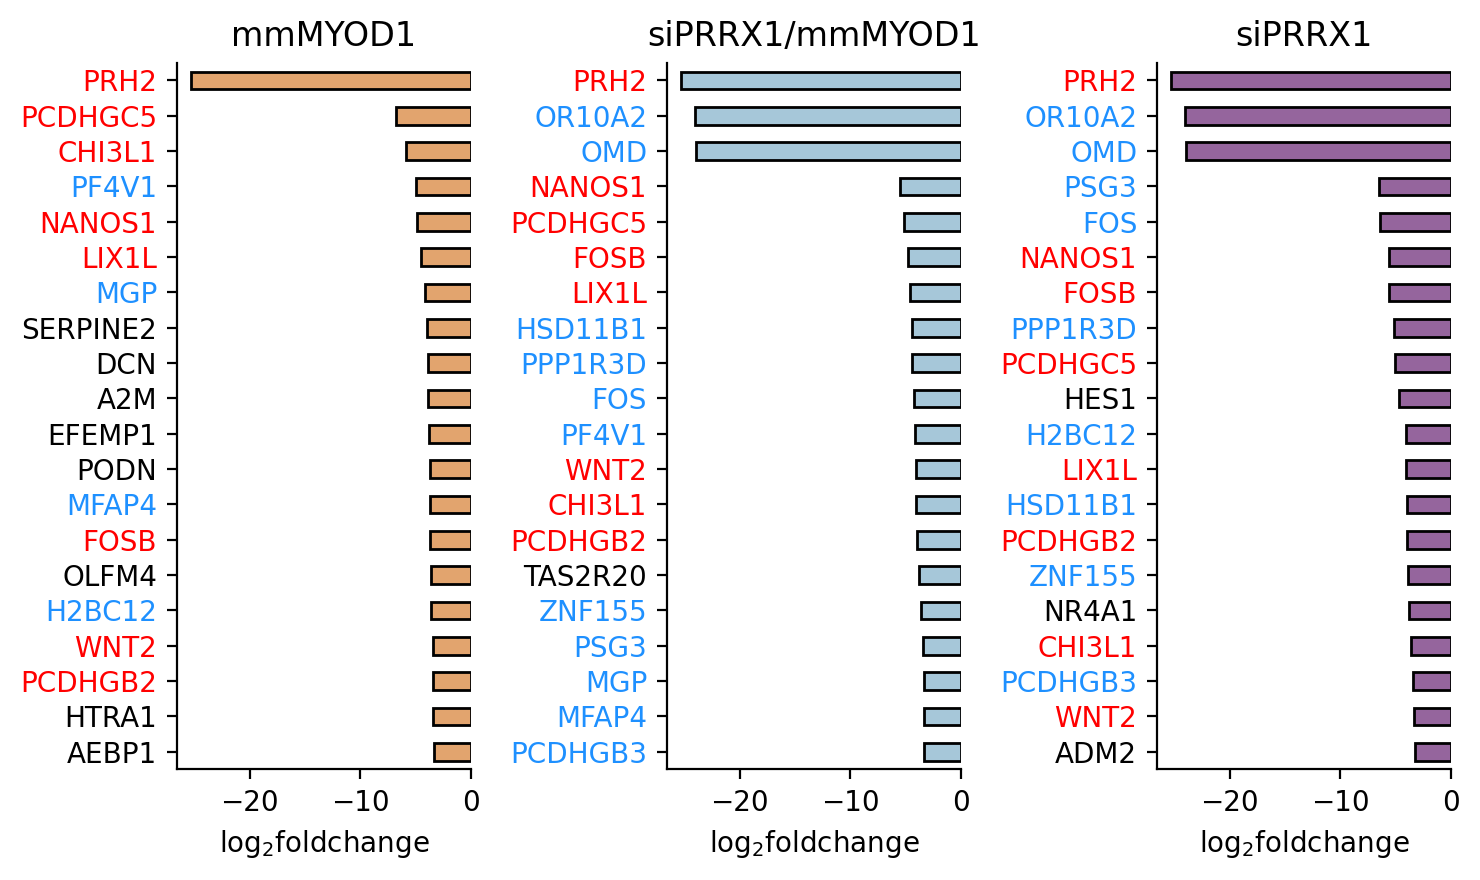

In [14]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20


top_genes_per_group = {}

for group in plot_order:
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = pdf[pdf['group'] == group].sort_values(by='logfoldchanges', ascending=True).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")


    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

## Top Fib genes

In [19]:
fdf = pdf[pdf['names'].isin(fib_genes)]

print(fdf.shape)
print(fdf['names'].nunique())

for i in fdf['group'].unique():
    tmp = fdf[fdf['group'] == i]
    print(f"N upregulated genes for {i}: {tmp[tmp['logfoldchanges'] > 0]['names'].nunique()}")
    print(f"N downregulated genes for {i}: {tmp[tmp['logfoldchanges'] < 0]['names'].nunique()}\n")


fdf.head()

(322, 11)
145
N upregulated genes for mmMYOD1: 16
N downregulated genes for mmMYOD1: 100

N upregulated genes for siPRRX1: 14
N downregulated genes for siPRRX1: 88

N upregulated genes for siPRRX1/mmMYOD1: 10
N downregulated genes for siPRRX1/mmMYOD1: 94



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
11,mmMYOD1,NFAT5,48.234932,2.557106,0.000000e+00,0.000000e+00,0.856330,2.557106,protein_coding,False,False
51,mmMYOD1,RUNX1,37.844135,2.331592,0.000000e+00,0.000000e+00,0.778094,2.331592,protein_coding,False,False
205,mmMYOD1,NFKB1,27.579325,2.363063,1.969867e-167,9.067905e-166,0.550972,2.363063,protein_coding,False,False
609,mmMYOD1,LAMA2,18.442032,1.712337,6.042637e-76,1.187753e-74,0.441916,1.712337,protein_coding,False,False
634,mmMYOD1,IL6,18.033573,1.764895,1.062030e-72,2.020924e-71,0.458985,1.764895,protein_coding,False,False


In [23]:
fdf[fdf['group'] == 'mmMYOD1'].sort_values(by='logfoldchanges', ascending=True).head(10)

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc,gene_type,mt,ribo
2355,mmMYOD1,MGP,-6.348534,-4.179555,2.173765e-10,1.069248e-09,0.009483,4.179555,protein_coding,False,False
3833,mmMYOD1,DCN,-65.366089,-3.934522,0.000000e+00,0.000000e+00,0.523471,3.934522,protein_coding,False,False
3703,mmMYOD1,EFEMP1,-41.455582,-3.786108,0.000000e+00,0.000000e+00,0.086297,3.786108,protein_coding,False,False
3179,mmMYOD1,PODN,-17.720663,-3.720052,2.904669e-70,5.344506e-69,0.025130,3.720052,protein_coding,False,False
3442,mmMYOD1,MFAP4,-25.433582,-3.708087,1.072631e-142,4.075998e-141,0.039829,3.708087,protein_coding,False,False
3480,mmMYOD1,FOSB,-26.619019,-3.680415,4.089367e-156,1.726913e-154,0.028924,3.680415,protein_coding,False,False
3479,mmMYOD1,HTRA1,-26.593523,-3.415228,8.066299e-156,3.389199e-154,0.050261,3.415228,protein_coding,False,False
3824,mmMYOD1,MMP2,-62.882145,-3.304433,0.000000e+00,0.000000e+00,0.394500,3.304433,protein_coding,False,False
2437,mmMYOD1,FMOD,-7.413795,-3.290248,1.227351e-13,7.017197e-13,0.013751,3.290248,protein_coding,False,False
3836,mmMYOD1,COL1A2,-66.875877,-3.280268,0.000000e+00,0.000000e+00,0.869606,3.280268,protein_coding,False,False


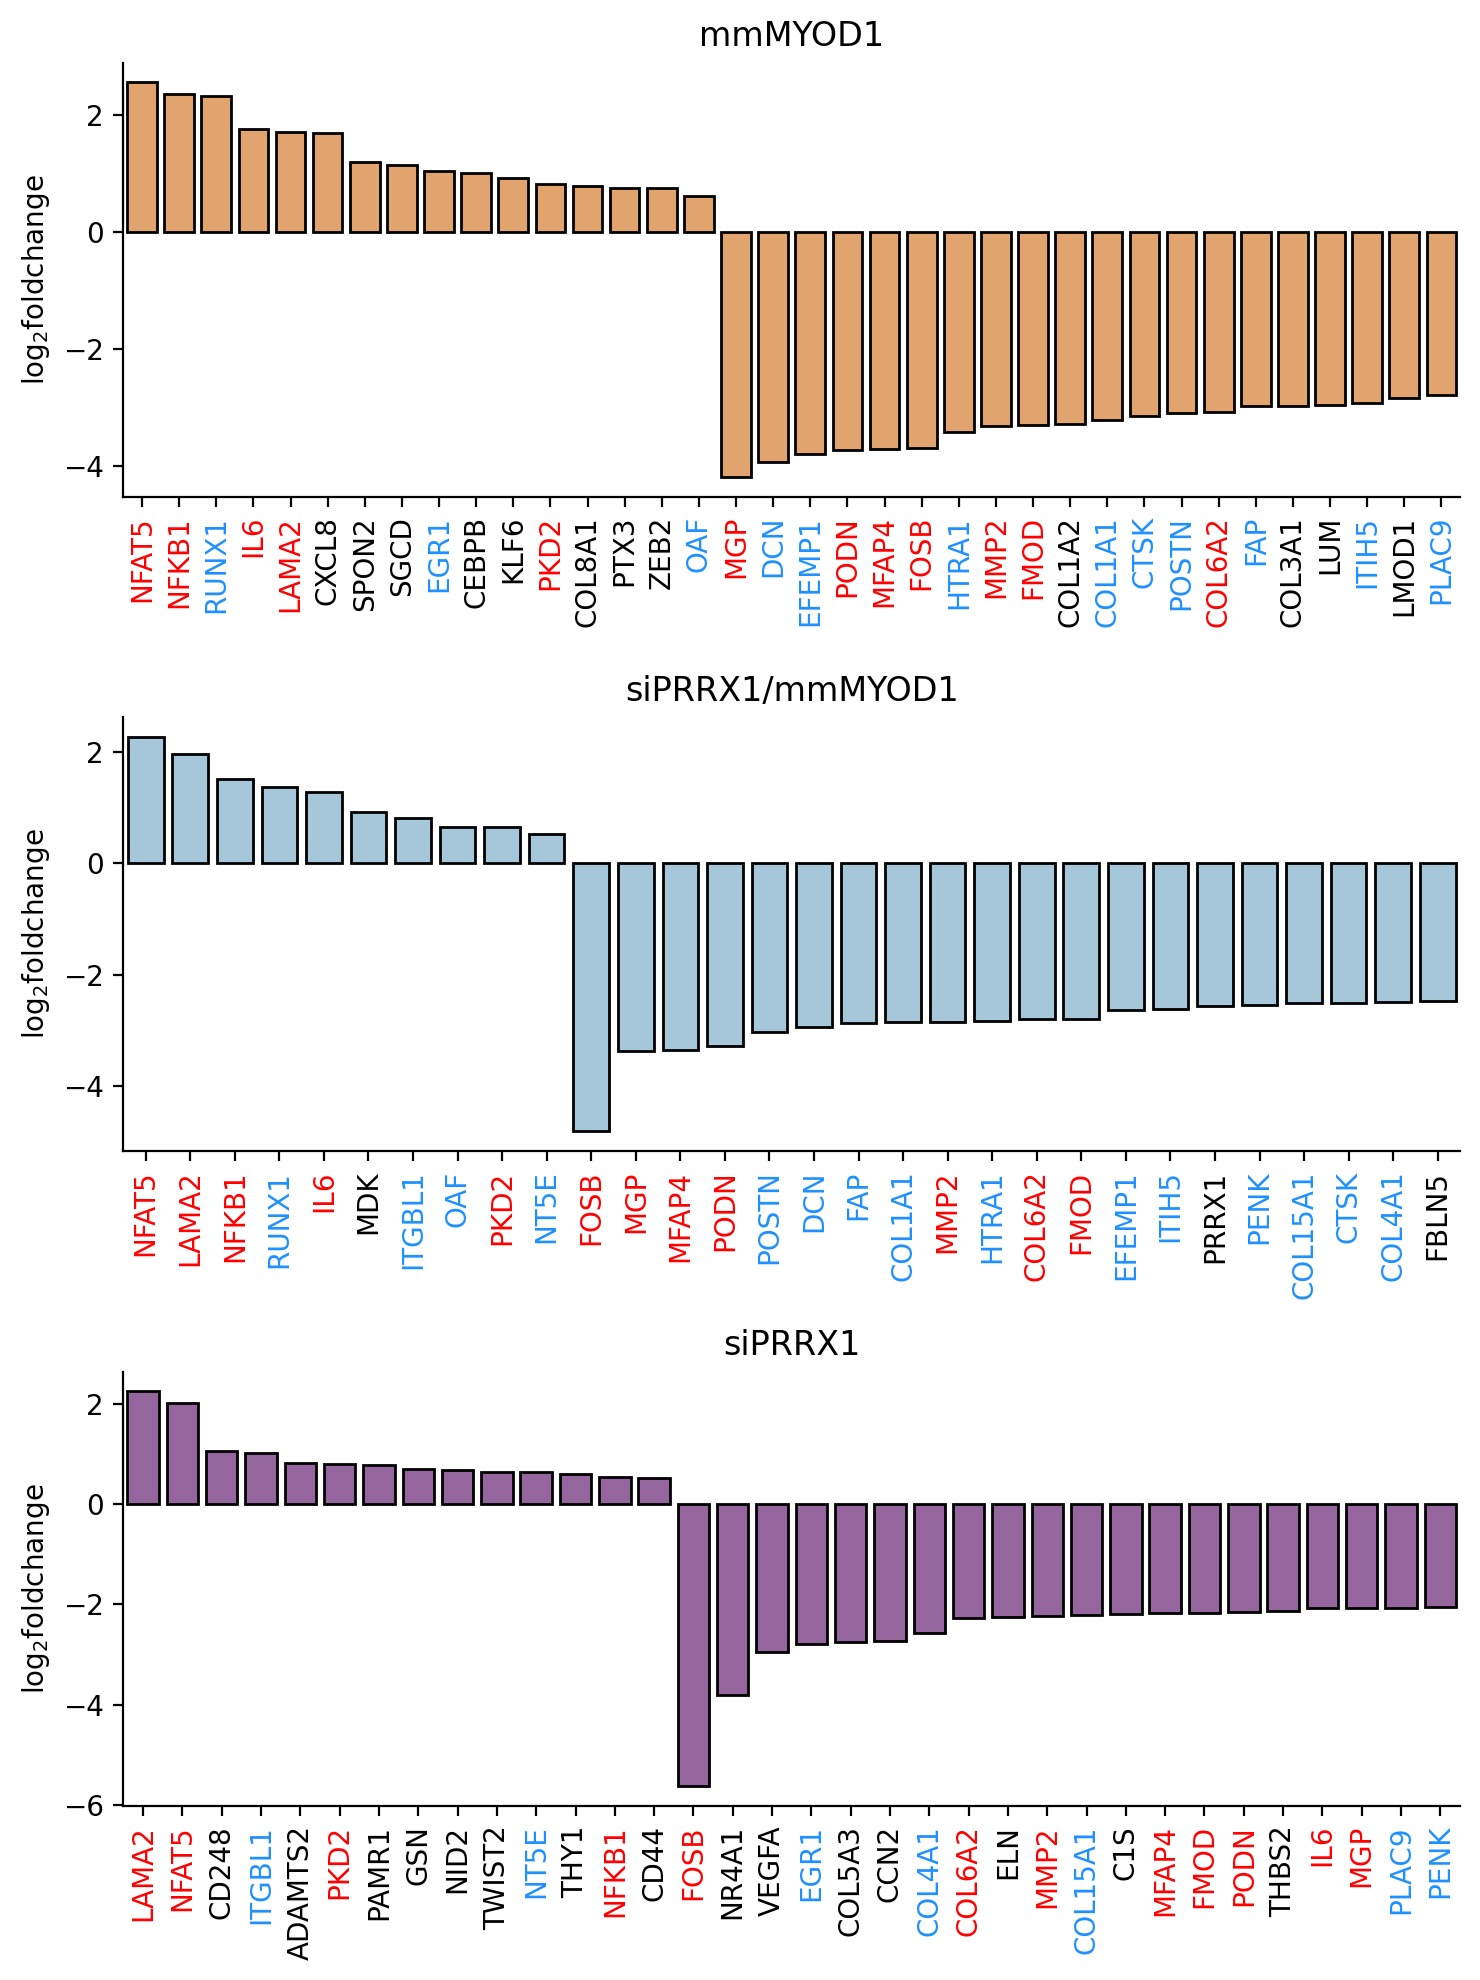

In [26]:
fdf = pdf[pdf['names'].isin(fib_genes)]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 10  # taller for combined up+down

fig, axs = plt.subplots(nrows=3, ncols=1) # 3 rows, 1 column

n_genes = 20

top_genes_per_group = {}

plot_order = ["mmMYOD1", "siPRRX1/mmMYOD1", "siPRRX1"]
color_map = {
    "siPRRX1": "#9B5CA6",
    "siPRRX1/mmMYOD1": "#9ECAE1",
    "mmMYOD1": "#F5A35B",
    "Control": "silver"
}

# Step 1: Get top up- and down-regulated genes per group
for group in plot_order:
    df_group = fdf[fdf['group'] == group]
    
    up = df_group[df_group['logfoldchanges'] > 0]
    down = df_group[df_group['logfoldchanges'] < 0]

    top_up = up.sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    top_down = down.sort_values(by='logfoldchanges', ascending=True).head(n_genes)

    top_genes_per_group[group] = pd.concat([top_up, top_down])  # combine up + down

# Step 2: Count appearances across groups
gene_counts = Counter()
for df_group in top_genes_per_group.values():
    gene_counts.update(df_group['names'])

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

# Step 4: Plot
for i, group in enumerate(plot_order):
    df = top_genes_per_group[group]
    ax = axs[i]

    sns.barplot(
        data=df,
        y='logfoldchanges',
        x='names',
        ax=ax,
        # width=0.5,
        color=color_map[group],
        edgecolor='k'
    )

    ax.set_title(group)
    ax.set_ylabel("log$_2$foldchange")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)

    for tick in ax.get_xticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')

sns.despine()
plt.tight_layout()
plt.show()

In [27]:
def clean_and_print(header, gene_set):
    genes = sorted(g for g in gene_set if not g.startswith("Z"))
    print(f"\n{header}\n")
    print(", ".join(genes) if genes else "(none)")
    print("\n" + "=" * 50)

    
fdf = pdf[pdf['names'].isin(fib_genes)]

up = fdf[fdf['logfoldchanges'] > 0]
down = fdf[fdf['logfoldchanges'] < 0]

odf = up.copy()


mmMYOD1 = set(odf[odf['group'] == 'mmMYOD1']['names'])
hyb = set(odf[odf['group'] == 'siPRRX1/mmMYOD1']['names'])
siPRRX1 = set(odf[odf['group'] == 'siPRRX1']['names'])    
    
shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

LAMA2, NFAT5, NFKB1, PKD2


Unique to MYOD1+ cells...

IL6, OAF, RUNX1


Unique to PRRX1- cells...

ITGBL1, NT5E


Unique to siPRRX1 only...

ADAMTS2, CD248, CD44, GSN, NID2, PAMR1, THY1, TWIST2


Unique to mmMYOD1 only...

CEBPB, COL8A1, CXCL8, EGR1, KLF6, PTX3, SGCD, SPON2


Unique to HYB...

MDK



In [30]:
# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for cond in up['group'].unique():
    tmp = up[up['group'] == cond]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    
    gene_list = tmp['names'].unique()

    enr = gget.enrichr(
        gene_list,
        database,
        save=False,
    )
    
    print(f"{cond}:")
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(25))
    print("=" * 100 + "\n")

14:46:13 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


mmMYOD1:


,path_name,overlapping_genes,adj_p_val
0,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[NFAT5, EGR1, IL6, CEBPB, KLF6, ZEB2, NFKB1, RUNX1]",0.000110
1,Inflammatory Response (GO:0006954),"[IL6, CEBPB, CXCL8, PTX3, NFKB1]",0.000207
2,Positive Regulation of DNA-templated Transcription (GO:0045893),"[NFAT5, EGR1, IL6, CEBPB, KLF6, ZEB2, NFKB1, RUNX1]",0.000207
3,Cellular Response to Cytokine Stimulus (GO:0071345),"[NFAT5, EGR1, IL6, CXCL8, NFKB1]",0.000207
4,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[EGR1, IL6, CEBPB, KLF6, NFKB1, RUNX1]",0.000207
5,Positive Regulation of miRNA Metabolic Process (GO:2000630),"[EGR1, IL6, NFKB1]",0.000589
6,Cellular Response to Interleukin-1 (GO:0071347),"[EGR1, CXCL8, NFKB1]",0.000629
7,Regulation of Leukocyte Adhesion to Vascular Endothelial Cell (GO:1904994),"[NFAT5, IL6]",0.001813
8,Acute-Phase Response (GO:0006953),"[CEBPB, IL6]",0.002220
9,Positive Regulation of Cell Differentiation (GO:0045597),"[IL6, CEBPB, LAMA2, NFKB1]",0.002711


14:46:13 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.



siPRRX1:


,path_name,overlapping_genes,adj_p_val
0,Cell-Matrix Adhesion (GO:0007160),"[ITGBL1, THY1, NID2, CD44]",0.000178
1,Positive Regulation of Leukocyte Cell-Cell Adhesion (GO:1903039),"[NFAT5, THY1, CD44]",0.000556
2,Extracellular Matrix Organization (GO:0030198),"[ADAMTS2, GSN, NID2]",0.020048
3,Integrin-Mediated Signaling Pathway (GO:0007229),"[ITGBL1, THY1]",0.045433
4,Epithelial Cell Apoptotic Process (GO:1904019),[GSN],0.045433
5,Regulation of Establishment of T Cell Polarity (GO:1903903),[GSN],0.045433
6,Regulation of Hyaluronan Biosynthetic Process (GO:1900125),[NFKB1],0.045433
7,Regulation of Vitamin D Biosynthetic Process (GO:0060556),[NFKB1],0.045433
8,Regulation of Basement Membrane Organization (GO:0110011),[LAMA2],0.045433
9,Negative Regulation of Vitamin Metabolic Process (GO:0046137),[NFKB1],0.045433


14:46:14 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.



siPRRX1/mmMYOD1:


,path_name,overlapping_genes,adj_p_val
0,Regulation of Leukocyte Adhesion to Vascular Endothelial Cell (GO:1904994),"[NFAT5, IL6, MDK]",0.000007
1,Positive Regulation of Leukocyte Adhesion to Vascular Endothelial Cell (GO:1904996),"[NFAT5, IL6, MDK]",0.000011
2,Positive Regulation of Leukocyte Cell-Cell Adhesion (GO:1903039),"[NFAT5, IL6, MDK]",0.000188
3,Positive Regulation of Cell Differentiation (GO:0045597),"[IL6, LAMA2, MDK, NFKB1]",0.000856
4,Regulation of Leukocyte Chemotaxis (GO:0002688),"[IL6, MDK]",0.002060
5,Regulation of Tissue Remodeling (GO:0034103),"[MDK, RUNX1]",0.002060
6,Regulation of Collagen Biosynthetic Process (GO:0032965),"[IL6, RUNX1]",0.002060
7,Positive Regulation of Extracellular Matrix Organization (GO:1903055),"[IL6, RUNX1]",0.002060
8,Cellular Response to Interleukin-6 (GO:0071354),"[IL6, NFKB1]",0.002060
9,Regulation of Extracellular Matrix Organization (GO:1903053),"[LAMA2, RUNX1]",0.002060


In [32]:
odf = down.copy()

mmMYOD1 = set(odf[odf['group'] == 'mmMYOD1']['names'])
hyb = set(odf[odf['group'] == 'siPRRX1/mmMYOD1']['names'])
siPRRX1 = set(odf[odf['group'] == 'siPRRX1']['names'])    
    
shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

ACTA2, BGN, C1R, C1S, CCDC80, CCN2, CLEC3B, COL15A1, COL16A1, COL1A1, COL1A2, COL3A1, COL4A1, COL4A2, COL5A1, COL5A3, COL6A1, COL6A2, COL7A1, CTHRC1, CTSK, CXCL14, DCN, DKK3, EFEMP1, EFEMP2, ELN, EMILIN1, FAP, FBLN2, FBLN5, FMOD, FOSB, FSTL1, GREM1, HTRA1, IGFBP3, ITIH5, LMOD1, LOX, LTBP2, LUM, MFAP4, MGP, MMP14, MMP2, MMP3, MXRA5, NNMT, NR4A1, OLFML3, PENK, PLAC9, PODN, POSTN, PRRX1, RARRES2, SERPINH1, SOD3, SPARC, TAGLN, THBS2


Unique to MYOD1+ cells...

ADAM33, CDH11, COL12A1, COL13A1, COL6A3, COPZ2, CXCL12, CYBRD1, FBN1, FKBP10, FKBP7, FN1, IGFBP7, ISLR, LAMA4, LAMC1, MEDAG, MYL9, P4HA1, PBX1, PDGFRA, PDGFRB, S100A4, VIM


Unique to PRRX1- cells...

ANGPTL2, CYP1B1, DAB2, HIF1A, KLF9, TIMP3, VEGFA


Unique to siPRRX1 only...

ABI3BP, CD55, CEBPB, CXCL3, CXCL8, EGR1, FGF2, FOSL2, IL1R1, IL6, KLF2, KLF4, KLF6, NGF, NR4A2, PTX3, SULF1, SYNPO2


Unique to mmMYOD1 only...

CD248, CKAP4, COL5A2, COX7A1, HSPB6, IGFBP6, LAMB1, MFAP5, OLFML2B, P4HTM, PCDH18, S

In [75]:
deg[deg['names'] == 'POSTN']

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
24033,mmMYOD1,POSTN,-12.798363,-3.095217,1.674440e-37,1.808945e-36,0.049312
49404,siPRRX1,POSTN,-11.280207,-1.782873,1.643586e-29,1.660964e-28,0.098834
74426,siPRRX1/mmMYOD1,POSTN,-15.203545,-3.025311,3.349923e-52,4.928834e-51,0.050130


In [37]:
database = "GO_Biological_Process_2025"

enr = gget.enrichr(
    list(unique_siPRRX1),
    database,
    save=False,
)

display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(10))

14:50:40 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


,path_name,overlapping_genes,adj_p_val
0,Positive Regulation of Transcription by RNA Polymerase II (GO:0045944),"[NR4A2, EGR1, CEBPB, IL6, KLF6, KLF4, KLF2, FOSL2]",0.000229
1,Positive Regulation of T Cell Cytokine Production (GO:0002726),"[IL6, IL1R1, CD55]",0.000229
2,Positive Regulation of RNA Biosynthetic Process (GO:1902680),"[EGR1, CEBPB, IL6, KLF6, KLF4, KLF2]",0.000676
3,Positive Regulation of DNA-templated Transcription (GO:0045893),"[NR4A2, EGR1, CEBPB, IL6, KLF6, KLF4, KLF2, FOSL2]",0.000676
4,Positive Regulation of Cytokine Production (GO:0001819),"[EGR1, CEBPB, IL6, IL1R1, SULF1]",0.000676
5,Positive Regulation of miRNA Transcription (GO:1902895),"[EGR1, IL6, KLF4]",0.000689
6,Positive Regulation of Macromolecule Biosynthetic Process (GO:0010557),"[EGR1, IL6, CXCL8, NGF, KLF4]",0.000740
7,Positive Regulation of miRNA Metabolic Process (GO:2000630),"[EGR1, IL6, KLF4]",0.000744
8,Cellular Response to Interleukin-1 (GO:0071347),"[EGR1, CXCL8, IL1R1]",0.000824
9,Regulation of miRNA Transcription (GO:1902893),"[EGR1, IL6, KLF4]",0.001126


In [38]:
# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database = 'GO_Cellular_Component_2025'
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for cond in down['group'].unique():
    tmp = down[down['group'] == cond]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=True)
    
    gene_list = tmp['names'].unique()

    enr = gget.enrichr(
        gene_list,
        database,
        save=False,
    )
    
    print(f"{cond}:")
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(10))
    print("=" * 100 + "\n")

14:54:27 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


mmMYOD1:


,path_name,overlapping_genes,adj_p_val
0,Extracellular Matrix Organization (GO:0030198),"[COL15A1, COL16A1, COL13A1, COL12A1, LAMC1, CTSK, SERPINH1, POSTN, LUM, MMP2, MMP3, COL1A1, GREM1, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, LOX, COL5A1, P4HA1, COL4A1, COL5A3, COL7A1, COL5A2]",1.542256e-26
1,Collagen Fibril Organization (GO:0030199),"[COL1A1, GREM1, COL3A1, COL1A2, COL5A1, LOX, P4HA1, LUM, COL5A3, COL12A1, COL5A2, SERPINH1]",1.021777e-15
2,External Encapsulating Structure Organization (GO:0045229),"[POSTN, COL15A1, COL16A1, COL13A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1, COL5A2]",1.551470e-15
3,Extracellular Structure Organization (GO:0043062),"[POSTN, COL15A1, COL16A1, COL13A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1, COL5A2]",1.551470e-15
4,Supramolecular Fiber Organization (GO:0097435),"[LUM, COL12A1, LMOD1, FBLN5, COL1A1, GREM1, MFAP4, COL3A1, EFEMP2, COL1A2, LOX, COL5A1, P4HA1, COL5A3, COL5A2, SERPINH1, EMILIN1, VIM, MYL9]",6.875918e-13
5,Endodermal Cell Differentiation (GO:0035987),"[MMP14, COL4A2, LAMA4, MMP2, COL7A1, COL12A1, COL6A1, FN1, LAMB1]",3.789984e-12
6,Endoderm Formation (GO:0001706),"[MMP14, COL4A2, LAMA4, MMP2, COL7A1, COL12A1, COL6A1, FN1, LAMB1]",1.072626e-11
7,Elastic Fiber Assembly (GO:0048251),"[MFAP4, EFEMP2, EMILIN1, FBLN5]",1.679141e-06
8,Eye Morphogenesis (GO:0048592),"[MFAP5, EFEMP1, COL5A1, COL5A2, FBN1]",6.489273e-06
9,Cell-Matrix Adhesion (GO:0007160),"[COL3A1, COL13A1, CDH11, FN1, EMILIN1, THY1, FBLN5]",7.224635e-05


14:54:28 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.



siPRRX1:


,path_name,overlapping_genes,adj_p_val
0,Extracellular Matrix Organization (GO:0030198),"[COL15A1, POSTN, COL16A1, LUM, MMP2, MMP3, COL1A1, GREM1, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, LOX, COL5A1, COL4A1, COL5A3, CTSK, COL7A1, SERPINH1, CYP1B1]",2.291403e-21
1,External Encapsulating Structure Organization (GO:0045229),"[COL15A1, POSTN, COL16A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1]",5.994078e-13
2,Extracellular Structure Organization (GO:0043062),"[COL15A1, POSTN, COL16A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1]",5.994078e-13
3,Collagen Fibril Organization (GO:0030199),"[COL1A1, GREM1, COL3A1, COL1A2, COL5A1, LOX, LUM, COL5A3, SERPINH1, CYP1B1]",1.039272e-12
4,Supramolecular Fiber Organization (GO:0097435),"[LUM, LMOD1, FBLN5, COL1A1, GREM1, MFAP4, COL3A1, EFEMP2, COL1A2, LOX, COL5A1, COL5A3, SERPINH1, CYP1B1, EMILIN1]",3.843469e-09
5,Regulation of Angiogenesis (GO:0045765),"[IL6, CXCL8, SPARC, COL4A2, CYP1B1, EMILIN1, THBS2, KLF4, SULF1, HIF1A, DCN, VEGFA]",2.167740e-08
6,Negative Regulation of Angiogenesis (GO:0016525),"[SPARC, COL4A2, EMILIN1, THBS2, KLF4, SULF1, DCN, KLF2]",1.003273e-06
7,Elastic Fiber Assembly (GO:0048251),"[MFAP4, EFEMP2, EMILIN1, FBLN5]",1.395445e-06
8,Negative Regulation of Blood Vessel Morphogenesis (GO:2000181),"[SPARC, COL4A2, EMILIN1, THBS2, KLF4, SULF1, DCN]",7.458719e-06
9,Endodermal Cell Differentiation (GO:0035987),"[MMP14, COL4A2, MMP2, COL7A1, COL6A1]",2.482462e-05


14:54:28 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.



siPRRX1/mmMYOD1:


,path_name,overlapping_genes,adj_p_val
0,Extracellular Matrix Organization (GO:0030198),"[COL15A1, COL16A1, COL13A1, COL12A1, LAMC1, CTSK, SERPINH1, CYP1B1, POSTN, LUM, MMP2, MMP3, COL1A1, GREM1, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, LOX, COL5A1, P4HA1, COL4A1, COL5A3, COL7A1]",3.251146e-27
1,Collagen Fibril Organization (GO:0030199),"[COL1A1, GREM1, COL3A1, COL1A2, COL5A1, LOX, P4HA1, LUM, COL5A3, COL12A1, SERPINH1, CYP1B1]",5.589972e-16
2,External Encapsulating Structure Organization (GO:0045229),"[POSTN, COL15A1, COL16A1, COL13A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1]",2.676865e-14
3,Extracellular Structure Organization (GO:0043062),"[POSTN, COL15A1, COL16A1, COL13A1, MMP2, MMP3, COL3A1, MMP14, COL1A2, CCDC80, COL4A2, COL4A1, COL5A3, COL7A1]",2.676865e-14
4,Supramolecular Fiber Organization (GO:0097435),"[LUM, COL12A1, LMOD1, FBLN5, COL1A1, GREM1, MFAP4, COL3A1, EFEMP2, COL1A2, LOX, COL5A1, P4HA1, COL5A3, SERPINH1, CYP1B1, EMILIN1, VIM, MYL9]",2.447307e-13
5,Endodermal Cell Differentiation (GO:0035987),"[MMP14, COL4A2, LAMA4, MMP2, COL7A1, COL12A1, COL6A1, FN1]",2.208658e-10
6,Endoderm Formation (GO:0001706),"[MMP14, COL4A2, LAMA4, MMP2, COL7A1, COL12A1, COL6A1, FN1]",5.363728e-10
7,Elastic Fiber Assembly (GO:0048251),"[MFAP4, EFEMP2, EMILIN1, FBLN5]",1.558249e-06
8,Extracellular Matrix Assembly (GO:0085029),"[MFAP4, EFEMP2, EMILIN1, FBLN5]",1.163989e-04
9,Endothelial Cell Migration (GO:0043542),"[NR4A1, FN1, CYP1B1, FSTL1, VEGFA]",1.551696e-04


## Venns

N unique upregulated genes: 3658
N unique downregulated genes: 1383

['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']


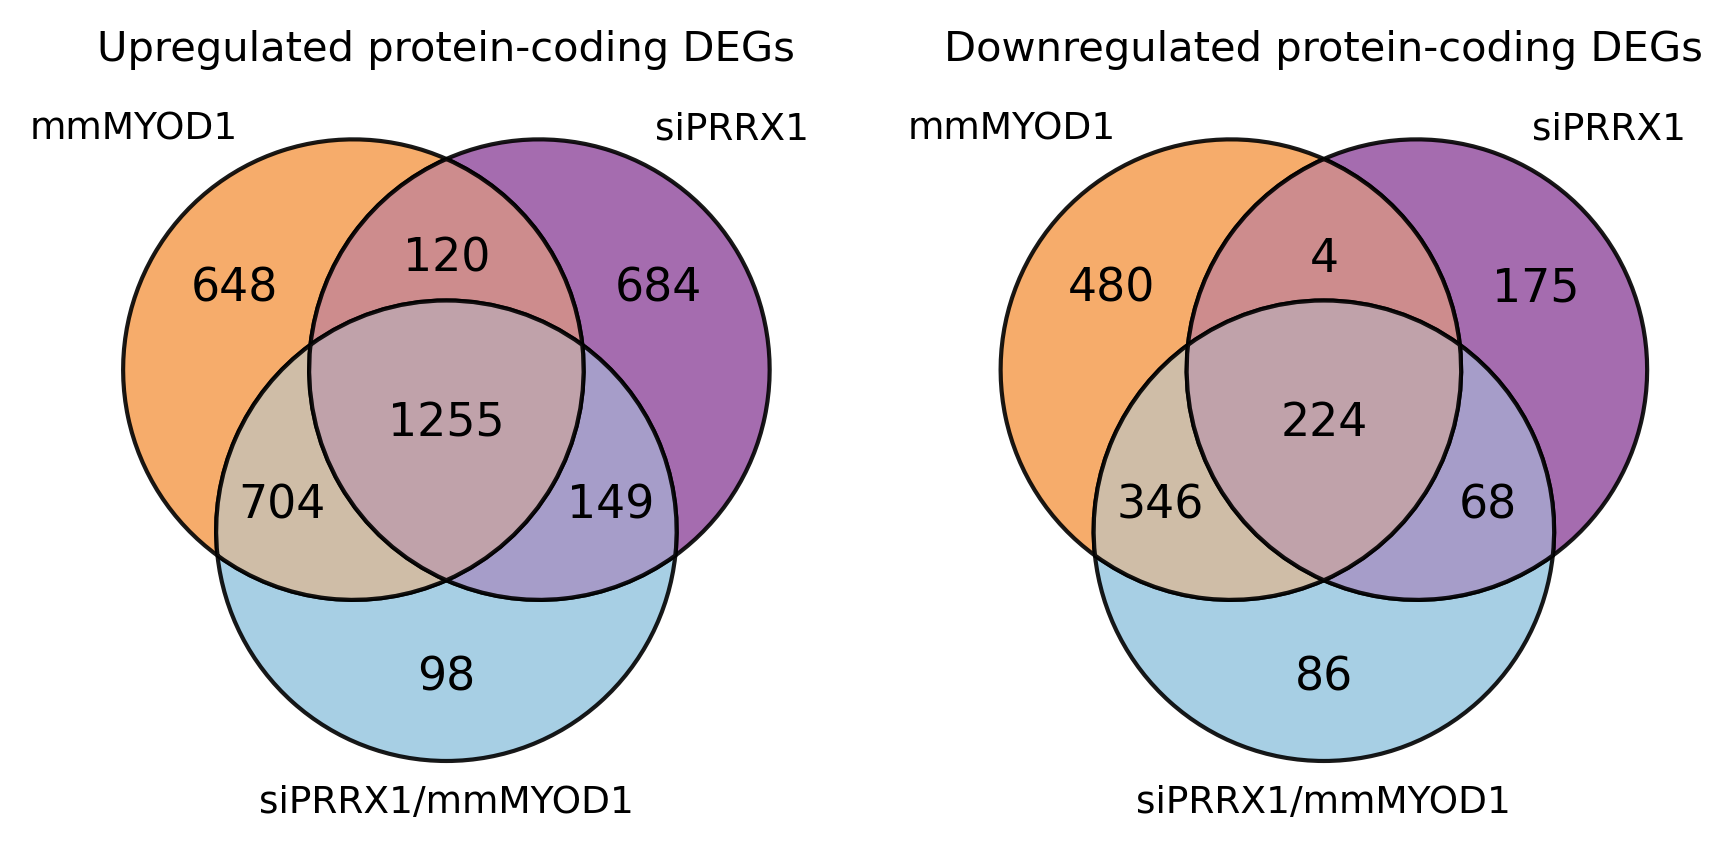

In [26]:
up = pdf[pdf['logfoldchanges'] > 0]
print(f"N unique upregulated genes: {up['names'].nunique()}")

down = pdf[pdf['logfoldchanges'] < 0]
print(f"N unique downregulated genes: {down['names'].nunique()}\n")


up_sets = up.groupby('group')['names'].apply(set).to_dict()
down_sets = down.groupby('group')['names'].apply(set).to_dict()

group_names = list(up_sets.keys())  # Assuming same groups in both
print(group_names)

# Colors
colors_rgb = {
    'mmMYOD1': mcolors.to_rgb('#F5A35B'), # orange
    'siPRRX1': mcolors.to_rgb('#9B5CA6'), # purple
    'siPRRX1/mmMYOD1': mcolors.to_rgb('#9ECAE1') # blue
}

def blend(colors):
    # get mix of 2 colors
    arr = np.array(colors)
    return tuple(arr.mean(axis=0))

venn_ids = {
    '100': ['mmMYOD1'],
    '010': ['siPRRX1'],
    '001': ['siPRRX1/mmMYOD1'],
    '110': ['mmMYOD1', 'siPRRX1'],
    '101': ['mmMYOD1', 'siPRRX1/mmMYOD1'],
    '011': ['siPRRX1', 'siPRRX1/mmMYOD1'],
    '111': ['mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']
}

# Plotting
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (6, 3)

fig, axs = plt.subplots(1, 2)

for ax, gene_sets, title in zip(axs, [up_sets, down_sets], ['Upregulated', 'Downregulated']):
    plt.sca(ax)  

    venn = venn3_unweighted(
        [gene_sets[group_names[0]], gene_sets[group_names[1]], gene_sets[group_names[2]]],
        set_labels=(group_names[0], group_names[1], group_names[2])
    )

    for label in venn.set_labels:
        if label:
            label.set_fontsize(9)
            
    for subset_id, sets in venn_ids.items():
        patch = venn.get_patch_by_id(subset_id)
        if patch:
            color = blend([colors_rgb[s] for s in sets])
            patch.set_facecolor(color)
            patch.set_edgecolor('k')
            patch.set_linewidth(1)
            patch.set_alpha(0.9)
        label = venn.get_label_by_id(subset_id)
        if label:
            label.set_fontsize(11)
            label.set_horizontalalignment('center')
            label.set_verticalalignment('center')
            # label.set_color('white')
            # label.set_path_effects([
            #     path_effects.Stroke(linewidth=1.5, foreground='black'),
            #     path_effects.Normal()])
            x, y = label.get_position()
            offset = 0
            if subset_id == '101':  # nudge left
                offset = -0.04
            elif subset_id == '011': # nudge right
                offset = 0.04
            elif subset_id == '100':
                offset = 0.04
            elif subset_id == '010':
                offset = -0.04
            label.set_position((x + offset, y))
            if subset_id == '001':
                label.set_position((x, y + 0.03))

    ax.set_title(f"{title} protein-coding DEGs", fontsize=10)

plt.tight_layout()
plt.show()

In [29]:
# GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
go_cc_genes = cdf['gene_name'].unique()
# print(f"N unique GO cell cycle genes: {cdf['gene_name'].nunique()}")

# Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
regev_genes = [x.strip() for x in open(fpath)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

cc_genes = list(set(go_cc_genes) | set(regev_genes))
print(f"N unique CC genes: {len(cc_genes)}")

N unique CC genes: 235


In [30]:
def clean_and_print(header, gene_set):
    genes = sorted(g for g in gene_set if not g.startswith("Z"))
    print(f"\n{header}\n")
    print(", ".join(genes) if genes else "(none)")
    print("\n" + "=" * 50)

odf = down.copy()

odf = odf[~odf['names'].isin(cc_genes)]

mmMYOD1 = set(odf[odf['group'] == 'mmMYOD1']['names'])
hyb = set(odf[odf['group'] == 'siPRRX1/mmMYOD1']['names'])
siPRRX1 = set(odf[odf['group'] == 'siPRRX1']['names'])    
    
# shared_all = [g for g in shared if not g.startswith('Z')]
shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

AAK1, ACADVL, ACAP2, ACTN1, ADGRE3, AEBP1, AGRN, AGTRAP, AKT3, ALDH1L2, ANKRD36C, APPL1, ARPC5, ASS1, ATL3, ATP2A2, BGN, BOD1, C12orf57, C12orf75, C17orf49, C1R, C1S, C5orf24, CALD1, CALU, CARD19, CCDC80, CCDC85B, CCN1, CCPG1, CD109, CD59, CDH2, CENPQ, CHRAC1, CLEC11A, CLU, CNN2, COL1A1, COL1A2, COL3A1, COL4A1, COL4A2, COL5A1, COL6A1, COL6A2, COL7A1, COMMD6, CRIM1, CST3, CTHRC1, CTSA, CTSB, CTSK, CYB5A, CYC1, DCN, DEK, DESI2, DKK3, DPP4, DPYSL2, DSTN, EFEMP2, EIF4A3, ELN, EPAS1, FAAP20, FAP, FBLN1, FERMT2, FLNA, FSIP1, FSTL1, FTH1, GALNT2, GFPT1, GINM1, GNS, GPNMB, GREM1, GRN, H3-3A, HEBP2, HNRNPL, HSPA1A, HSPB1, ID2, IGFBP3, IGFBP4, ITGA1, ITGAE, ITM2B, JAK1, JUND, KIRREL1, KMT5A, KRAS, KRT10, LAGE3, LAMB2, LAMP1, LARS1, LEPROT, LMO4, LNPK, LONP1, LOX, LRP1, LUM, LY96, MARCKS, MFGE8, MGST1, MMP14, MMP2, MMP3, MRAS, MTDH, MTHFD2, MXRA8, MYADM, MZT2A, MZT2B, NARS1, NDFIP1, NDUFAF8, NFIX, NID1, NNMT, NPC2, NREP, NT5C, NUPR1, PAIP1, PAPPA, PCOLCE, PDLIM7, PFD

## enrichr

In [ ]:
group = 'mmMYOD1'

df = pdf[pdf['group'] == group]

print(f"N upregulated genes for {group}: {df[df['logfoldchanges'] > 0]['names'].nunique()}")
print(f"N downregulated genes for {group}: {df[df['logfoldchanges'] < 0]['names'].nunique()}")

df.head()

In [47]:
pd.set_option('display.max_colwidth', None)

groups = ['siPRRX1']
downregulated = False

n_genes = 200
database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

for cond in groups:
    tmp = pdf[pdf['group'] == cond]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=downregulated)
    
    gene_list = tmp['names'].unique()[:n_genes]

    enr = gget.enrichr(
        gene_list,
        database,
        save=False,
    )
    
    print(f"Cluster {cond}:")
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val']].head(25))
    print("=" * 100 + "\n")

17:46:42 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Cluster siPRRX1:


,path_name,overlapping_genes,adj_p_val
0,Negative Regulation of DNA Metabolic Process (GO:0051053),"[H1-5, H1-4, GMNN, H1-1, H1-3, H1-2]",0.003674
1,Chromosome Organization (GO:0051276),"[H1-5, H1-4, GMNN, H1-1, H1-3, H1-2]",0.004174
2,Chromosome Condensation (GO:0030261),"[H1-5, H1-4, H1-1, H1-3, H1-2]",0.005141
3,Regulation of DNA Recombination (GO:0000018),"[H1-5, H1-4, H1-1, H1-3, H1-2]",0.013880
4,Negative Regulation of DNA Recombination (GO:0045910),"[H1-5, H1-4, H1-1, H1-3, H1-2]",0.014124
5,Cytoskeleton Organization (GO:0007010),"[KISS1, RAC2, WDPCP, TNIK, SIPA1L3, KLHL20, SH3D19]",0.034152
6,Cellular Response to Fluid Shear Stress (GO:0071498),"[HAS2, MAP2K5, SREBF2]",0.034152
7,Proteasome-Mediated Ubiquitin-Dependent Protein Catabolic Process (GO:0043161),"[SMURF2, UBE3D, FAF1, FBXL17, MDM2, UBR3, KLHL22, ERCC8, FBXL2, FBXL14, KLHL20]",0.096272
8,Protein Localization to Microtubule Organizing Center (GO:1905508),"[C2CD3, CEP250, CEP192]",0.111110
9,Protein Localization to Centrosome (GO:0071539),"[C2CD3, CEP250, CEP192]",0.122411


## TFs

In [9]:
tfpath = "../../resources/allTFs_hg38.txt"

with open(tfpath, 'r') as file:
    tf_list = [line.strip() for line in file]

print(len(tf_list))

1892


In [19]:
# Indentify DE TFs 
deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='condition_vs_control',
)

sig = get_significant_DEGs(deg)
# sig.to_csv("../../tables/DE_vs_control.csv", index=False)
sig.head()

Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
N unique significant DEGs: 9882



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.0,0.0,1.000000,32.184513
1,mmMYOD1,MT-ND4,69.559166,2.778089,0.0,0.0,0.999526,2.778089
2,mmMYOD1,LINC-PINT,59.171329,2.708041,0.0,0.0,0.970128,2.708041
3,mmMYOD1,NAV3,58.639927,3.446840,0.0,0.0,0.924609,3.446840
4,mmMYOD1,TAF1D,55.636890,2.705306,0.0,0.0,0.960645,2.705306


In [11]:
tdf = sig[sig['names'].isin(tf_list)]
print(tdf['names'].nunique())

tdf.sort_values(by=['group', 'abs_lfc'], ascending=[True, False]).groupby('group').head()

890


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.000000e+00,0.000000e+00,1.000000,32.184513
48,mmMYOD1,ESR1,38.310966,8.280114,0.000000e+00,0.000000e+00,0.552394,8.280114
2860,mmMYOD1,ZNF704,7.038711,7.452746,1.940263e-12,1.056262e-11,0.101944,7.452746
1911,mmMYOD1,BACH2,9.891577,7.354721,4.528387e-23,3.503240e-22,0.143670,7.354721
2043,mmMYOD1,BOLL,9.413764,6.132032,4.786828e-21,3.494803e-20,0.137980,6.132032
27907,siPRRX1,ZNF704,7.859221,6.921099,3.865304e-15,2.539216e-14,0.095627,6.921099
50068,siPRRX1,FOS,-64.743675,-6.439006,0.000000e+00,0.000000e+00,0.026239,6.439006
49926,siPRRX1,NANOS1,-33.308788,-5.633697,2.880598e-243,2.604186e-241,0.010787,5.633697
49931,siPRRX1,FOSB,-33.551693,-5.625426,8.505851e-247,7.831012e-245,0.013120,5.625426
29846,siPRRX1,BACH2,4.514338,4.866530,6.351473e-06,2.538764e-05,0.056268,4.866530


In [13]:
tdf = tdf.sort_values(by=['group', 'abs_lfc'], ascending=[True, False])
print(tdf.shape)

# tdf.to_csv("../../tables/DE_TFs_vs_control.csv", index=False)
tdf.head()

(1890, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,abs_lfc
0,mmMYOD1,MYOD1,69.678673,32.184513,0.000000e+00,0.000000e+00,1.000000,32.184513
48,mmMYOD1,ESR1,38.310966,8.280114,0.000000e+00,0.000000e+00,0.552394,8.280114
2860,mmMYOD1,ZNF704,7.038711,7.452746,1.940263e-12,1.056262e-11,0.101944,7.452746
1911,mmMYOD1,BACH2,9.891577,7.354721,4.528387e-23,3.503240e-22,0.143670,7.354721
2043,mmMYOD1,BOLL,9.413764,6.132032,4.786828e-21,3.494803e-20,0.137980,6.132032


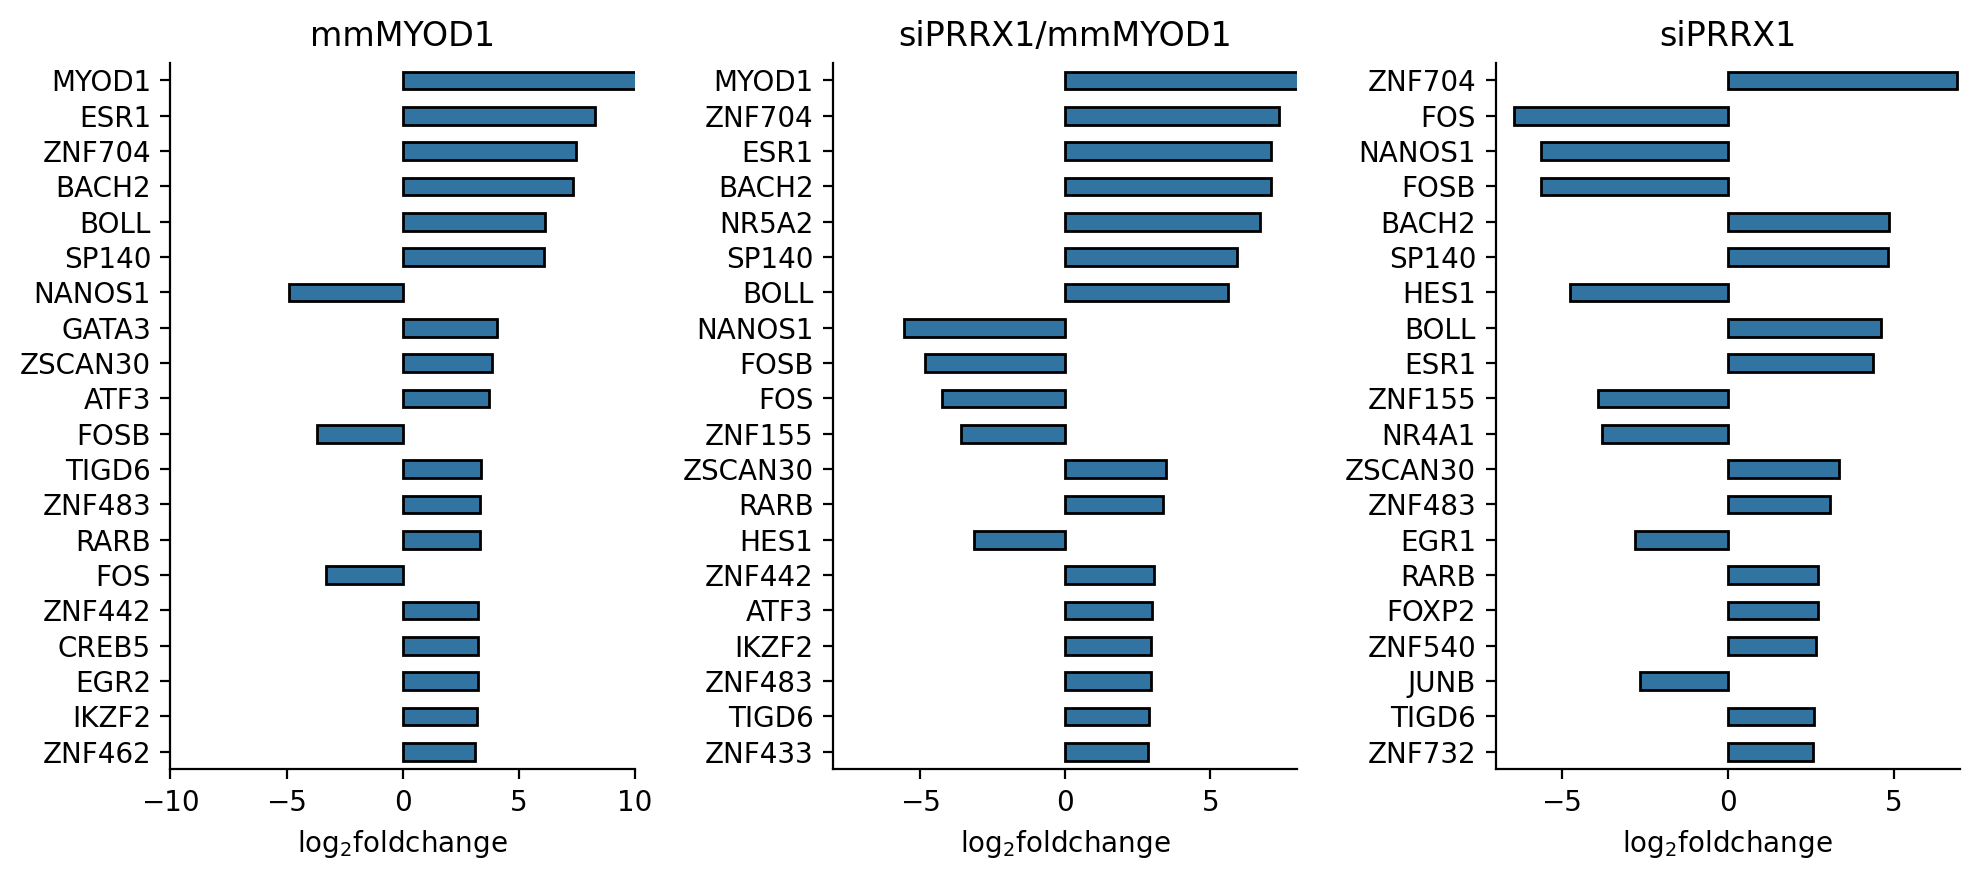

In [14]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

plot_order = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1']

for i, group in enumerate(plot_order): 
    df = tdf[tdf['group'] == group].sort_values(by='abs_lfc', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")
    
    if group == 'mmMYOD1':
        ax.set_xlim([-10, 10])
    elif group == 'siPRRX1/mmMYOD1':
        ax.set_xlim([-8, 8])
    else:
        ax.set_xlim([-7, 7])

sns.despine()
plt.tight_layout()
plt.show()

### Overlap

In [15]:
def clean_and_print(header, gene_set):
    genes = sorted(g for g in gene_set if not g.startswith("Z"))
    print(f"\n{header}\n")
    print(", ".join(genes) if genes else "(none)")
    print("\n" + "=" * 50)

tdf_up = tdf[tdf['logfoldchanges'] > 0]
odf = tdf_up.copy()

mmMYOD1 = set(odf[odf['group'] == 'mmMYOD1']['names'])
hyb = set(odf[odf['group'] == 'siPRRX1/mmMYOD1']['names'])
siPRRX1 = set(odf[odf['group'] == 'siPRRX1']['names'])    
    
# shared_all = [g for g in shared if not g.startswith('Z')]
shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

ABL1, ACO1, ASCC1, ASPSCR1, BACH2, BANP, BHLHE41, BNC2, BOLL, BPTF, BRF1, C19orf25, CBFA2T2, CCNT2, CHD1, CHD2, CLOCK, DDX20, DEAF1, E2F6, E2F7, ESR1, ETV6, EWSR1, EXOSC3, FLI1, FOSL1, FOXF1, FOXK2, FOXN2, FOXN3, FOXO1, FOXP2, FUBP1, GATAD2A, GLIS1, GPBP1L1, GTF2I, GTF2IRD1, HDAC8, HHAT, HIVEP2, HIVEP3, HMBOX1, HMGA2, IKZF2, JRK, JRKL, KDM2A, KDM2B, KDM4C, KLF12, KMT2A, LCOR, LCORL, LUZP1, MCTP2, MDM2, MECOM, MEF2A, MEIS1, MGA, MITF, MLLT10, MSANTD3, MSI2, MTF2, NCOA1, NCOA2, NCOA3, NELFA, NF1, NFAT5, NFATC3, NFE2L3, NFKB1, NFX1, NPAS2, NR2C2, NR3C2, NR6A1, NRF1, PAX3, PHF21A, PHF8, PHTF1, PIK3C3, POLR3A, POLR3G, POU2F1, POU2F2, POU6F1, PPARD, PPARG, PPP1R10, PQBP1, PRDM1, PRDM10, PRDM15, PRDM4, PRDM5, RARB, RCOR1, RFC2, RFX3, RFX7, RFX8, RIOK2, RREB1, RUFY3, RUNX2, SATB2, SCMH1, SETDB1, SFPQ, SNAPC4, SOX13, SOX15, SOX5, SP140, SSBP3, STAT4, STAT5B, TAF1, TAF7, TAF9, TCF7L1, TERF2, TFCP2, THRB, TIGD1, TIGD6, TIMM8A, TRPS1, USP39, UTP18, WDR83, YY2


Unique

In [16]:
gene_dict = {
    "shared_all": sorted(shared),
    "unique_to_MYODpos": sorted(unique_MYOD),
    "unique_to_PRRX1neg": sorted(unique_PRRX),
    "unique_to_siPRRX1_only": sorted(unique_siPRRX1),
    "unique_to_mmMYOD1_only": sorted(unique_mmMYOD1),
    "unique_to_HYB": sorted(unique_HYB),
}

max_len = max(len(lst) for lst in gene_dict.values())
overlap_up = pd.DataFrame({k: pd.Series(v) for k, v in gene_dict.items()})

print(overlap_up.shape)
# save table
# overlap_up.to_csv("../../tables/overlap_DE_TFs_up.csv", index=False)
overlap_up.head()

(319, 6)


,shared_all,unique_to_MYODpos,unique_to_PRRX1neg,unique_to_siPRRX1_only,unique_to_mmMYOD1_only,unique_to_HYB
0,ABL1,ADNP2,APEX2,ALX3,ADNP,CPSF4
1,ACO1,AEBP2,ARID3A,ARNT2,AHRR,HES4
2,ASCC1,AFF4,DMC1,BCLAF1,ARID5A,HTATIP2
3,ASPSCR1,ATF2,DPF1,CNOT6,ARNT,NMI
4,BACH2,ATF3,DTL,CSTF2,ATF1,NR5A2


In [17]:
tdf_down = tdf[tdf['logfoldchanges'] < 0]
odf = tdf_down.copy()

mmMYOD1 = set(odf[odf['group'] == 'mmMYOD1']['names'])
hyb = set(odf[odf['group'] == 'siPRRX1/mmMYOD1']['names'])
siPRRX1 = set(odf[odf['group'] == 'siPRRX1']['names'])    

shared = mmMYOD1 & hyb & siPRRX1
unique_MYOD = (mmMYOD1 & hyb) - siPRRX1
unique_PRRX = (siPRRX1 & hyb) - mmMYOD1
unique_siPRRX1 = siPRRX1 - mmMYOD1 - hyb
unique_mmMYOD1 = mmMYOD1 - siPRRX1 - hyb
unique_HYB = hyb - siPRRX1 - mmMYOD1

clean_and_print("Shared by all conditions...", shared)
clean_and_print("Unique to MYOD1+ cells...", unique_MYOD)
clean_and_print("Unique to PRRX1- cells...", unique_PRRX)
clean_and_print("Unique to siPRRX1 only...", unique_siPRRX1)
clean_and_print("Unique to mmMYOD1 only...", unique_mmMYOD1)
clean_and_print("Unique to HYB...", unique_HYB)


Shared by all conditions...

ARG2, CD59, CERS2, CHAMP1, DPF2, EPAS1, FOS, FOSB, FOXC1, HES1, ID2, ID4, IKZF4, JUND, MAF, NANOS1, NFATC4, NFIX, NR4A1, PCK2, PHF1, PHLDA2, PRDX5, PRRX1, PRRX2, PTPMT1, RB1, RBM17, SMAD6, TEAD3, THRA


Unique to MYOD1+ cells...

CAT, CDK2AP1, CREB3L1, DNAJC21, E2F8, FOXM1, HLTF, HMG20B, HMGB1, HOXC10, KIF22, MBNL2, MBTPS2, MSRB3, MXD3, MXD4, NUCB1, OSR2, P4HB, PBX1, RAB2A, RAD21, RPS10, SIX5, SMARCA1, SMARCC1, SMC3, STUB1, UQCRB, VAMP3


Unique to PRRX1- cells...

CEBPD, DAB2, GLIS2, HIF1A, JDP2, JUNB, KLF16, KLF9, LRRFIP1, MNT, MXI1, NFE2L1, NFIB, SMAD1, SMAD7, SNAI1, SOX11, SOX4, SRF, TRIB3, XBP1, YY1


Unique to siPRRX1 only...

ARID5A, ATF3, ATF4, BATF3, BHLHE40, CEBPB, CEBPG, EDN1, EGR1, ELF1, ETS2, FOSL2, HES4, IRF1, IRF2, IRF7, IRX5, JUN, KLF10, KLF13, KLF2, KLF3, KLF4, KLF6, KLF7, MAFF, MAFG, MAFK, MSC, NFATC2, NFIL3, NFKB2, NFYB, NKX3-1, NMI, NR3C1, NR4A2, NR4A3, PLAGL1, RARA, RNF114, SIX1, STAT1, STAT2, TGIF1, TRAF4, TRIM69, VDR


Unique to mmMY

In [18]:
gene_dict = {
    "shared_all": sorted(shared),
    "unique_to_MYODpos": sorted(unique_MYOD),
    "unique_to_PRRX1neg": sorted(unique_PRRX),
    "unique_to_siPRRX1_only": sorted(unique_siPRRX1),
    "unique_to_mmMYOD1_only": sorted(unique_mmMYOD1),
    "unique_to_HYB": sorted(unique_HYB),
}

max_len = max(len(lst) for lst in gene_dict.values())
overlap_down = pd.DataFrame({k: pd.Series(v) for k, v in gene_dict.items()})

print(overlap_down.shape)
# save table
# overlap_down.to_csv("../../tables/overlap_DE_TFs_down.csv", index=False)
overlap_down.head()

(51, 6)


,shared_all,unique_to_MYODpos,unique_to_PRRX1neg,unique_to_siPRRX1_only,unique_to_mmMYOD1_only,unique_to_HYB
0,ARG2,CAT,CEBPD,ARID5A,AKR1A1,AR
1,CD59,CDK2AP1,DAB2,ATF3,ANXA11,CXXC5
2,CERS2,CREB3L1,GLIS2,ATF4,CANX,FEZ1
3,CHAMP1,DNAJC21,HIF1A,BATF3,CFL2,FOXF2
4,DPF2,E2F8,JDP2,BHLHE40,DUSP22,GTF2A1
